# **Import the data:**

In [ ]:
import os
import random
import torch
from torch import nn, optim
from torchvision import transforms, models
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import Counter


In [ ]:
from google.colab import drive
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

drive.mount('/content/drive')
dataset_path = '/content/drive/MyDrive/Dataset'
healthy_path = os.path.join(dataset_path, 'Healthy')
autism_path = os.path.join(dataset_path, 'Autistic')
ndd_path = os.path.join(dataset_path, 'NDD')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Data Transformations:**

In [ ]:
random.seed(42)
torch.manual_seed(42)

save_dir = "/content/drive/MyDrive/processed_data"
os.makedirs(save_dir, exist_ok=True)

# Data transformations
preprocess_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

augmentation_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1))])


# Label mapping
label_mapping = {'Healthy': 0, 'Autistic': 1, 'NDD': 2}
data = []

for label_name, path in [('Healthy', healthy_path), ('Autistic', autism_path), ('NDD', ndd_path)]:
    for img in os.listdir(path):
        img_path = os.path.join(path, img)
        data.append((img_path, label_mapping[label_name]))

print(f"Total images: {len(data)}")

Total images: 4410


In [ ]:
class_counts = Counter([label for _, label in data])
print("Class distribution:", class_counts)

Class distribution: Counter({0: 1470, 1: 1470, 2: 1470})


## **Data Preprocessing and Splitting:**

In [ ]:
# Split dataset into train (70%), validation (15%), and test (15%)
train_ratio, val_ratio, test_ratio = 0.70, 0.15, 0.15
train_data, temp_data = train_test_split(data, test_size=(val_ratio + test_ratio), random_state=42, stratify=[label for _, label in data])
val_data, test_data = train_test_split(temp_data, test_size=0.50, random_state=42, stratify=[label for _, label in temp_data])

# Augment training data
augmented_train_data = []
for image_path, label in tqdm(train_data, desc="Processing training images", unit="image"):
    image = Image.open(image_path).convert("RGB")
    augmented_train_data.append((preprocess_transforms(image), label))  # Original
    augmented_image = augmentation_transforms(image)  # Apply augmentation
    augmented_train_data.append((preprocess_transforms(augmented_image), label))  # Then apply preprocessing

# Convert validation and test data
def process_images(data):
    return [(preprocess_transforms(Image.open(image_path).convert("RGB")), label) for image_path, label in data]

val_data = process_images(val_data)
test_data = process_images(test_data)

# Convert to TensorDataset and DataLoader
def create_dataloader(data, batch_size=32, shuffle=True):
    images, labels = zip(*data)
    return DataLoader(TensorDataset(torch.stack(images), torch.tensor(labels)), batch_size=batch_size, shuffle=shuffle)

train_loader = create_dataloader(augmented_train_data)
val_loader = create_dataloader(val_data, shuffle=False)
test_loader = create_dataloader(test_data, shuffle=False)

# Save processed datasets
torch.save(augmented_train_data, os.path.join(save_dir, "train_data.pt"))
torch.save(val_data, os.path.join(save_dir, "val_data.pt"))
torch.save(test_data, os.path.join(save_dir, "test_data.pt"))

print("Datasets saved successfully to:", save_dir)

# **Load the preprocessed data:**

In [ ]:
# Load datasets
train_data = torch.load(os.path.join(save_dir, "train_data.pt"))
val_data = torch.load(os.path.join(save_dir, "val_data.pt"))
test_data = torch.load(os.path.join(save_dir, "test_data.pt"))

print("Datasets loaded successfully!")

def create_dataloader(data, batch_size=32, shuffle=True):
    images, labels = zip(*data)
    images = torch.stack(images)
    labels = torch.tensor(labels)
    return DataLoader(TensorDataset(images, labels), batch_size=batch_size, shuffle=shuffle)

train_loader = create_dataloader(train_data, shuffle=True)
val_loader = create_dataloader(val_data, shuffle=False)
test_loader = create_dataloader(test_data, shuffle=False)

print("DataLoaders are ready for training and evaluation!")


Datasets loaded successfully!
DataLoaders are ready for training and evaluation!


# **ConvNext Model:**

In [ ]:
# model = models.convnext_base(weights="ConvNeXt_Base_Weights.IMAGENET1K_V1")
model = models.convnext_tiny(weights="ConvNeXt_Tiny_Weights.IMAGENET1K_V1")

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

for param in model.features[-4:].parameters():  # Unfreeze last 2 layers
    param.requires_grad = True

model.classifier[2] = nn.Sequential(
    nn.Linear(model.classifier[2].in_features, 512),
    nn.GELU(),
    nn.Dropout(p=0.5),
    nn.Linear(512, len(label_mapping)))

model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-3)
# optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=5e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-6, verbose=True)



/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [ ]:
print(model)

# **Train the model:**

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10, patience=5):
    best_val_loss, best_val_acc, epochs_without_improvement = float('inf'), 0.0, 0
    scaler = torch.cuda.amp.GradScaler()

    train_accuracies, val_accuracies, train_losses, val_losses = [], [], [], []

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}")

        # Training
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Validation
        model.eval()
        val_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                correct += (outputs.argmax(1) == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(val_loader)
        val_acc = correct / total
        scheduler.step(val_loss)  # Update learning rate based on validation loss

        print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}")

        # if val_loss < best_val_loss or val_acc > best_val_acc:
        #     best_val_loss, best_val_acc = val_loss, val_acc
        #     epochs_without_improvement = 0
        # else:
        #     epochs_without_improvement += 1
        #     if epochs_without_improvement >= patience:
        #         print("Early stopping...")
        #         break


        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        train_losses.append(train_loss)
        val_losses.append(val_loss)


# Train the model
train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=50)


<ipython-input-8-ef9f8ec37988>:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
<ipython-input-8-ef9f8ec37988>:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Epoch 1/50
Train Loss: 0.6707, Train Accuracy: 0.7679
Val Loss: 0.5824, Val Accuracy: 0.8351

Epoch 2/50
Train Loss: 0.4990, Train Accuracy: 0.8824
Val Loss: 0.5144, Val Accuracy: 0.8775

Epoch 3/50
Train Loss: 0.4239, Train Accuracy: 0.9295
Val Loss: 0.5024, Val Accuracy: 0.8729

Epoch 4/50
Train Loss: 0.3636, Train Accuracy: 0.9683
Val Loss: 0.5006, Val Accuracy: 0.8865

Epoch 5/50
Train Loss: 0.3388, Train Accuracy: 0.9798
Val Loss: 0.5059, Val Accuracy: 0.8865

Epoch 6/50
Train Loss: 0.3216, Train Accuracy: 0.9880
Val Loss: 0.5180, Val Accuracy: 0.8911

Epoch 7/50
Train Loss: 0.3125, Train Accuracy: 0.9909
Val Loss: 0.5492, Val Accuracy: 0.8850

Epoch 8/50
Train Loss: 0.3068, Train Accuracy: 0.9940
Val Loss: 0.5302, Val Accuracy: 0.9047

Epoch 9/50
Train Loss: 0.3070, Train Accuracy: 0.9934
Val Loss: 0.5326, Val Accuracy: 0.8986

Epoch 10/50
Train Loss: 0.3078, Train Accuracy: 0.9932
Val Loss: 0.5785, Val Accuracy: 0.8865

Epoch 11/50
Train Loss: 0.2992, Train Accuracy: 0.9976
Val

KeyboardInterrupt: 

# **Save the model:**

In [ ]:
# # Save only model weights for inference
# checkpoint_path = "/content/drive/MyDrive/autism_model_checkpoint.pth"
# torch.save(model.state_dict(), checkpoint_path)

# print(f"Model saved successfully at {checkpoint_path}")


In [ ]:
model_path = "/content/drive/MyDrive/autism_model.pth"
torch.save(model, model_path)
print(f"Model saved successfully at {model_path}")


# **Evaluate the model:**

In [ ]:
# Evaluate on test set
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")


Test Accuracy: 90.94%


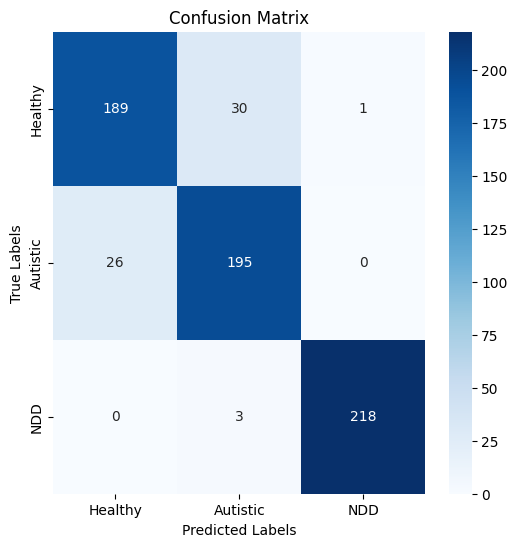

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.88      0.86      0.87       220
    Autistic       0.86      0.88      0.87       221
         NDD       1.00      0.99      0.99       221

    accuracy                           0.91       662
   macro avg       0.91      0.91      0.91       662
weighted avg       0.91      0.91      0.91       662



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


true_labels = []
predicted_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        true_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(predicted.cpu().numpy())

true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

# Confusion Matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=list(label_mapping.keys()), yticklabels=list(label_mapping.keys()))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Classification Report:
report = classification_report(true_labels, predicted_labels, target_names=list(label_mapping.keys()))
print("Classification Report:")
print(report)


# **Visualize the results:**

-SNE scatter plot:

In [ ]:
from sklearn.manifold import TSNE

model.eval()
features = []
labels_list = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        features.append(outputs.cpu().numpy())
        labels_list.append(labels.cpu().numpy())

features = np.concatenate(features)
labels_list = np.concatenate(labels_list)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
features_2d = tsne.fit_transform(features)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=labels_list, cmap='jet', alpha=0.6)
plt.colorbar(scatter, label="Class")
plt.title("t-SNE Visualization of Feature Embeddings")
plt.show()


ROC curve:

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

num_classes = len(label_mapping)

true_labels = []
predicted_probs = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)  # Convert logits to probabilities

        true_labels.extend(labels.cpu().numpy())
        predicted_probs.extend(probs.cpu().numpy())

true_labels = np.array(true_labels)
predicted_probs = np.array(predicted_probs)

# Convert true labels to one-hot encoding
true_labels_one_hot = label_binarize(true_labels, classes=np.arange(num_classes))

# Compute ROC Curve and AUC for each class
plt.figure(figsize=(10, 8))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(true_labels_one_hot[:, i], predicted_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'Class {list(label_mapping.keys())[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color="navy", linestyle="--")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend(loc="lower right")
plt.show()


Top 3 classes:

In [ ]:
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
import torch
import torch.nn.functional as F

def preprocess_image(image):
    """
    Preprocesses the image (resize, convert to RGB, tensor conversion, normalization).
    """
    image = image.convert("RGB")
    image = image.resize((224, 224))
    image = transforms.ToTensor()(image)
    image = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])(image)
    return image

def predict_top_3_classes(image_path, model, label_mapping, device):
    image = Image.open(image_path)
    plt.imshow(image)
    plt.axis('off')
    plt.show()

    image_tensor = preprocess_image(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = F.softmax(outputs, dim=1)

    top3_probabilities, top3_indices = torch.topk(probabilities, 3, dim=1)

    top3_classes = [list(label_mapping.keys())[i] for i in top3_indices[0]]

    print("Top 3 Predictions:")
    for i in range(3):
        print(f"Class: {top3_classes[i]}, Probability: {top3_probabilities[0][i].item():.4f}")

image_path = '/content/drive/MyDrive/new-data-for-testing/Autism_test.jpg'
predict_top_3_classes(image_path, model, label_mapping, device)


# **Interpretability with Grad-CAM (XAI):**

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms, models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the model (ensure classifier structure matches training)
model_path = "/content/drive/MyDrive/autism_model_checkpoint.pth"
model = models.convnext_base(weights="ConvNeXt_Base_Weights.IMAGENET1K_V1")

# Modify classifier to match training
model.classifier[2] = torch.nn.Sequential(
    torch.nn.Linear(model.classifier[2].in_features, 512),
    torch.nn.ReLU(),
    torch.nn.Dropout(p=0.5),
    torch.nn.Linear(512, 3)
)

model.to(device)

# Load trained weights
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

activations = None
gradients = None

def forward_hook(module, input, output):
    global activations
    activations = output

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

target_layer = model.features[-1]
target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)

def preprocess_image(image_path):
    image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    return transform(image).unsqueeze(0).to(device)

def grad_cam(image_path, model):
    global activations, gradients

    input_tensor = preprocess_image(image_path)

    output = model(input_tensor)
    class_idx = output.argmax(dim=1).item()

    model.zero_grad()
    output[0, class_idx].backward()

    weights = torch.mean(gradients, dim=[2, 3], keepdim=True)
    cam = torch.sum(weights * activations, dim=1).squeeze().cpu().detach().numpy()

    cam = np.maximum(cam, 0)
    cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam))

    return cam, class_idx

def visualize_cam(image_path, cam):
    original_image = cv2.imread(image_path)
    original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
    height, width, _ = original_image.shape

    cam = cv2.resize(cam, (width, height))

    # Convert CAM to heatmap
    heatmap = np.uint8(255 * cam)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Blend original image with heatmap
    overlay = cv2.addWeighted(original_image, 0.5, heatmap, 0.5, 0)

    plt.figure(figsize=(6, 6))
    plt.imshow(overlay)
    plt.axis('off')
    plt.show()



In [ ]:
image_path = "/content/drive/MyDrive/new-data-for-testing/healthy_test.jpg"
cam, predicted_class = grad_cam(image_path, model)
visualize_cam(image_path, cam)

print(f"Predicted Class Index: {predicted_class}")

In [ ]:
image_path = "/content/drive/MyDrive/new-data-for-testing/Autism_test.jpg"
cam, predicted_class = grad_cam(image_path, model)
visualize_cam(image_path, cam)

print(f"Predicted Class Index: {predicted_class}")

In [ ]:
image_path = "/content/drive/MyDrive/new-data-for-testing/NDD_test.jpg"
cam, predicted_class = grad_cam(image_path, model)
visualize_cam(image_path, cam)

print(f"Predicted Class Index: {predicted_class}")

In [ ]:
image_path = "/content/drive/MyDrive/Dataset/NDD/NDD_duplication_syndrome20.jpg"
cam, predicted_class = grad_cam(image_path, model)
visualize_cam(image_path, cam)

print(f"Predicted Class Index: {predicted_class}")

In [ ]:
image_path = "//content/drive/MyDrive/Dataset/NDD/NDD_deletion_syndrome18.jpg"
cam, predicted_class = grad_cam(image_path, model)
visualize_cam(image_path, cam)

print(f"Predicted Class Index: {predicted_class}")